## OpenCV 入门
### 1.了解和安装 OpenCV-Python
#### Python语法简洁、编写高效，但相比C/C++运行慢很多。然而Python可以很容易地扩展C/C++。OpenCV-Python就是用Python包装了C++的实现，背后实际就是C++的代码在跑，运行速度非常接近原生。另外，图像是矩阵数据，OpenCV-Python原生支持Numpy，为矩阵运算、科学计算提供了极大的便利性。
### 安装
#### 只需终端下的一条指令：


In [ ]:
!pip install opencv-python
!pip install numpy

Python的版本可以在终端中输入python --version来查看。

对于OpenCV，打开Python的开发环境，输入import cv2，运行没有报错说明一切正常。要查看OpenCV的版本，可以：


In [ ]:
import cv2
print(cv2.__version__)

### 2.图像基本操作
#### 2.1 使用cv2.imread()来读入一张图片
参数1：图片的文件名
- 如果图片放在当前文件夹下，直接写文件名就行，如'cats.jpeg'
- 否则需要给出绝对路径，如'D:\OpenCVSamples\cats.jpeg'

参数2：读入方式，省略即采用默认值
- cv2.IMREAD_COLOR：彩色图，默认值(1)
- cv2.IMREAD_GRAYSCALE：灰度图(0)
- cv2.IMREAD_UNCHANGED：包含透明通道的彩色图(-1)

返回值：numpy array对象

小tips：路径中不能有中文，并且没有加载成功的话是不会报错的，print(img)的结果为None，后面用到时才会报错，千万别踩坑。

In [ ]:
img = cv2.imread("cats.jpeg")             #读入一幅小猫图像
print(img.size)
print(img.dtype)
print(img.shape)
# 形状中包括行数、列数和通道数
height, width, channels = img.shape

# img是灰度图的话：height, width = img.shape

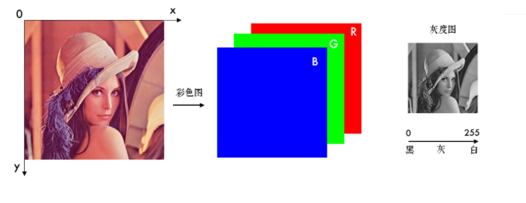

图像属性获取：img.shape获取图像的形状，图片是彩色的话，返回一个包含行数（高度）、列数（宽度）和通道数的元组，灰度图只返回行数和列数：

img.dtype获取图像数据类型，img.size获取图像总像素数。

#### 2.2 使用cv2.imshow()显示图片，窗口会自适应图片的大小
- 参数1：窗口的名字
- 参数2：要显示的图片

不同窗口之间用窗口名区分，所以窗口名相同就表示是同一个窗口。

In [ ]:
import cv2
img = cv2.imread("cats.jpeg")  
cv2.imshow("cats", img)                   #显示出这幅图像

cv2.waitKey(0)                            #弹出图像框，需手动关闭，不然程序阻塞在这里
cv2.destroyAllWindows()
cv2.waitKey(1) 

cv2.waitKey()是等待用户键盘输入，参数是等待时间（毫秒ms）。时间一到，会继续执行接下来的程序，传入0的话表示一直等待。等待期间获取用户的按键输入(Ascii码)：k = cv2.waitKey(0)。

**假如用opencv读取图像，但配合其他库来显示**

就需要在cv2.cvtColor函数中，配置参数cv2.COLOR_BGR2RGB，将BGR转换为RGB。

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 使用OpenCV读取图像
img_bgr = cv2.imread("cats.jpeg")

# 转换为RGB格式以供matplotlib显示
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 使用matplotlib显示图像
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_bgr)  # 错误的颜色（因为matplotlib期望RGB格式）
plt.title("BGR (Wrong colors in matplotlib)")

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)  # 正确的颜色
plt.title("RGB (Correct colors)")
plt.show()

#### 2.3 使用cv2.imwrite()保存图片

- 参数1：包含后缀名的文件名
- 参数2：图像

In [ ]:
cv2.imwrite('cat_gray.jpg', img)

# 试试真的保存一张灰度图的小猫图，再看看它的shape


是不是很简单~~~

### 3.像素点的基本操作
#### 3.1 获取和修改像素点的值

我们通过行列的坐标来获取某像素点的值，对于彩色图，结果是[ B,G,R ]。对于灰度图只有一个值。  
**读取值的时候，要注意第三个值的索引范围**

In [ ]:
import cv2
img = cv2.imread("cats.jpeg")

px = img[400, 208]
print(px)  # [142 154 188]

# 只获取蓝色blue通道的值
px_blue = img[400,208,0]
print(px_blue)  # 142

修改像素点的值

In [ ]:
img = cv2.imread("cats.jpeg")
img[400:450,200:250] = [0,0,0]  

cv2.imshow("cats", img) 
cv2.waitKey(0)                            #弹出图像框，需手动关闭，不然程序阻塞在这里
cv2.destroyAllWindows()
cv2.waitKey(1) 

**OpenCV中的坐标系**
- 坐标原点: 位于图像的左上角。
- x轴: 代表列，方向从左到右。这对应于图像的宽度 (width)。
- y轴: 代表行，方向从上到下。这对应于图像的高度 (height)。

> **思考**  
如何生成一个300x480 纯蓝的图？

In [ ]:
import cv2
import numpy as np
### start code here


### end code
cv2.imshow('img', imgblue)  
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1) 

#### 3.2 ROI：Region of Interest 感兴趣区域

比如我们要检测眼睛，而眼睛肯定在脸上，所以我们感兴趣的只有脸这，其他都不关心。
那么可以单独把脸截取出来，大大节省计算量，提高运行速度。

截取ROI非常简单，指定图片的范围即可。

In [ ]:
img = cv2.imread("cats.jpeg")
observerArea = img[167:647,425:618]
cv2.imshow("Observer",observerArea)
cv2.waitKey(0)                            
cv2.destroyAllWindows()
cv2.waitKey(1) 

> **思考** 如何将cat.jpeg的右下角水印去掉，而且尽量没有违和感

In [ ]:
import cv2

img = cv2.imread('cats.jpeg')
cv2.imshow('src',img)
print(img.shape)
### start code 

### end code
cv2.imshow('dst',img)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1) 

### 4.绘图功能
当我们找到图像中的一些特征（轮廓等），可以通过画线、圆和矩形等形状标记出来，也可以给图片添加文字。
绘制形状的函数有一些共同的参数：
- img：要绘制形状的图片
- color：绘制的颜色：彩色图就传入BGR的一组值，如蓝色就是(255,0,0)，灰度图，传入一个灰度值
- thickness：线宽，默认为1；对于矩形/圆之类的封闭形状而言，传入-1表示填充形状

**tips：所有绘图函数均会直接影响原图片，如果不想影响原图，可以用img.copy()生成一份拷贝再画。**

#### 4.1 画线
画直线只需指定起点和终点的坐标：

In [ ]:
import cv2
import numpy as np

# 创建一副黑色的图片
img = np.zeros((512, 512, 3), np.uint8)
img_cp= img.copy()

# 画一条线宽为5的蓝色直线，参数2：起点，参数3：终点，参数4：颜色，参数5：线宽
cv2.line(img_cp, (0, 0), (512, 512), (255, 0, 0), 5)

cv2.imshow('img',img_cp)
cv2.waitKey(0)                            
cv2.destroyAllWindows()
cv2.waitKey(1) 

#### 4.2 画矩形
画矩形需要知道左上角和右下角的坐标

In [ ]:
# 画一个绿色边框的矩形，参数2：左上角坐标，参数3：右下角坐标
img = np.zeros((512, 512, 3), np.uint8)
cv2.rectangle(img, (384, 0), (510, 128), (0, 255, 0), 3)

cv2.imshow('img',img)
cv2.waitKey(0)                            
cv2.destroyAllWindows()
cv2.waitKey(1) 

#### 4.3 画圆
画圆需要指定圆心和半径，注意下面的例子中线宽=-1代表填充

In [ ]:
# 画一个填充红色的圆，正好在方框里
# 参数2：圆心坐标，参数3：半径，参数4：颜色，参数5：线宽

#start code here

#end code here

cv2.imshow('img',img)
cv2.waitKey(0)                            
cv2.destroyAllWindows()
cv2.waitKey(1) 

#### 4.4 添加文字
使用cv2.putText()添加文字，它的参数也比较多：
- 参数2：要添加的文本
- 参数3：文字的起始坐标（左下角为起点）
- 参数4：字体
- 参数5：文字大小（缩放比例）

In [ ]:

font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(img, 'OpenCV', (10, 500), font,
            4, (255, 255, 255), 2, lineType=cv2.LINE_AA)
cv2.imshow('img',img)
cv2.waitKey(0)                            
cv2.destroyAllWindows()
cv2.waitKey(1) 

### 5.视频操作
#### 5.1 使用摄像头

需要使用cv2.VideoCapture(0)创建VideoCapture对象，参数0指的是摄像头的编号，
**如果你电脑上有两个摄像头的话，访问第2个摄像头就可以传入1，依此类推。**

- 操作流程，先占用，再读取，最后释放,一定要记得释放！


In [ ]:
camera = cv2.VideoCapture(0)

while True:
    ret, frame = camera.read()             # 一帧一帧采集图像   
    cv2.imshow('Press q to Exit',frame)              # 显示图像
    
    if cv2.waitKey(1) == ord('q'):  # 按下q键退出
        break

camera.release()                           # 释放摄像头
cv2.destroyAllWindows()
cv2.waitKey(1) 

#### 小练习：用opencv打开摄像头拍一张照片并保存到本地

In [ ]:
import cv2

def take_and_save_photo(filename="test.jpg"):
    """
    使用默认摄像头拍摄一张照片并保存到本地。
    """
    # 1. 打开默认摄像头 (通常索引为 0)
    

    # 2. 检查摄像头是否成功打开
    if not cap.isOpened():
        print("错误：无法打开摄像头。")
        return

    print("摄像头已打开。请对准摄像头，3秒后将进行拍照...")
    
    # 等待几秒钟，给用户准备时间
    cv2.waitKey(3000) 

    # 3. 从摄像头读取一帧图像
    

    # 4. 检查是否成功读取到帧
    if not ret:
        print("错误：无法从摄像头捕获图像。")
    else:
        # 5. 将捕获到的帧保存为图片文件
        
        print(f"照片已成功拍摄并保存为 '{filename}'")

    # 6. 释放摄像头资源
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

if __name__ == '__main__':
    take_and_save_photo()


camera.read()函数返回的第1个参数ret是一个布尔值，表示当前这一帧是否获取正确。第二个参数返回当前帧的数字矩阵（即图像本身）

#### 5.2 播放本地视频
跟打开摄像头一样，如果把摄像头的编号换成视频的路径就可以播放本地视频了。

想一下cv2.waitKey()，它的参数表示暂停时间，所以这个值越大，视频播放速度越慢，反之，播放速度越快，通常设置为25或30。


In [ ]:
# 播放本地视频
capture = cv2.VideoCapture('orange.mp4')
frame_w = capture.get(cv2.CAP_PROP_FRAME_WIDTH)
frame_h = capture.get(cv2.CAP_PROP_FRAME_HEIGHT)
fps = capture.get(cv2.CAP_PROP_FPS)
print(frame_w,frame_h,fps)

while(capture.isOpened()):
    ret, frame = capture.read()
    if ret:
        cv2.imshow('frame', frame)
        if cv2.waitKey(30) == ord('q'):
            break
    else:
        break

capture.release()
cv2.destroyAllWindows() 
cv2.waitKey(1) 

#### 5.3 录制视频
之前我们保存图片用的是cv2.imwrite()，要保存视频，我们需要创建一个VideoWriter的对象，需要给它传入四个参数：
- 输出的文件名，如'output.avi'
- 编码方式FourCC码
- 帧率FPS
- 要保存的分辨率大小 这个地方需要注意，先宽后高

FourCC是用来指定视频编码方式的四字节码，所有的编码可参考Video Codecs(https://www.fourcc.org/codecs.php)。

In [ ]:
import cv2
capture = cv2.VideoCapture(0)

# 定义编码方式并创建VideoWriter对象
fourcc = cv2.VideoWriter_fourcc(*'MJPG')
outfile = cv2.VideoWriter('output.avi', fourcc, 25, (640, 480))

while capture.isOpened():
    ret, frame = capture.read()

    if ret:
        outfile.write(frame)  # 写入文件
        cv2.imshow('frame', frame)
        if cv2.waitKey(1) == ord('q'):
            print(frame.shape)
            break
    else:
        break
outfile.release()

capture.release()
cv2.destroyAllWindows()
cv2.waitKey(1) 

#### 5.4 采集图像数据集

In [ ]:
import numpy as np
import cv2
import time
import os
from PIL import Image

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

font                   = cv2.FONT_HERSHEY_SIMPLEX
bottomLeftCornerOfText = (10, 25)
fontScale              = 1
fontColor              = (255,255,255)
lineType               = 2

print('Input image class index: ', end = '')
class_index = input()

print('Input maximum image number of class {}: '.format(class_index), end = '')
max_image_num = input()


folder_path = os.path.join('./data', str(class_index))
if not os.path.exists(folder_path):
    os.mkdir(folder_path)

i = 0
while True:
    ret, frame = cap.read()

    saved_file_path = os.path.join(folder_path, 'image_' + str(i) + '.png')
    cv2.imwrite(saved_file_path, frame)

    cv2.putText(frame,'Image: ' + str(i), 
        bottomLeftCornerOfText, 
        font, 
        fontScale,
        fontColor,
        lineType)

    cv2.imshow('frame', frame)
    cv2.waitKey(100)
    i+=1

# Esc (Escape) 键 的ASCII码是27
    if cv2.waitKey(1) == 27 or i >= int(max_image_num):
        break

cap.release()

cv2.destroyAllWindows()
cv2.waitKey(1) 

### 6 边缘检测与卷积运算
边缘检测是图像处理和计算机视觉中，尤其是特征提取的一个重要研究领域。边缘检测的目的是标识数字图像中亮度变化较为明显的点，这些点通常存在于目标、背景区域之间，是图像分割的重要依据。

边缘检测常用的算法有: Sobel算法、拉普拉斯算法、Canny算法等。


In [ ]:
import cv2
import numpy as np

img = cv2.imread("cats.jpeg",0)
convolutionCore = np.array((
                            [-1,-1,-1],
                            [-1,8,-1],
                            [-1,-1,-1]))#拉普拉斯拓展卷积核

#新像素值 = (8 * 中心像素) - (周围8个像素的总和)。
#平滑区域（中心像素的值和周围像素的平均值接近，计算结果会接近 0。
#边缘区域（颜色/灰度急剧变化），中心像素的值和周围像素差异很大，计算结果的绝对值会很大（亮白色或纯黑色），从而将边缘凸显出来

res = cv2.filter2D(img,-1,convolutionCore)        #使用opencv的卷积函数
# -1 表示输出图像 res 将与输入图像 img 具有相同的深度。

cv2.imshow('frame',res)
cv2.waitKey(0)                           
cv2.destroyAllWindows()
cv2.waitKey(1)

## 7. OpenCV 中的机器学习
OpenCV中有很多机器学习模块，比如人脸检测、SVM分类器。以人脸检测为例：OpenCV 提供了两种人脸检测方法，包括：
- 基于 Haar 级联的人脸检测器
- 基于深度学习的人脸检测器

#### 7.1 基于 Haar 级联的人脸检测器

OpenCV 提供了 4 个级联分类器用于人脸检测，可以从OpenCV 官方下载这些级联分类器文件：
- haarcascade_frontalface_alt.xml 
- haarcascade_frontalface_alt2.xml 
- haarcascade_frontalface_alt_tree.xml 
- haarcascade_frontalface_default.xml 

总的来说这些分类器具有相似的准确率.

OpenCV 提供了 cv2.CascadeClassifier() 函数用于从文件中加载分类器：

In [ ]:
faceCascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

cv2.CascadeClassifier.detectMultiScale() 函数检测对象并将它们作为矩形列表返回。下面是完整的视频流人脸检测代码：

In [ ]:
import cv2              
cap = cv2.VideoCapture(0) 

while cap.isOpened():
    ret, img = cap.read()             
    if ret:  
        # 颜色信息对于检测人脸不是必需的，并且灰度图计算量更小、速度更快
        gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

        #加载OpenCV预先训练好的人脸检测模型
        faceCascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
        faces_rects = faceCascade.detectMultiScale(gray,scaleFactor = 1.05,minNeighbors = 1,minSize = (30,30),flags = cv2.CASCADE_SCALE_IMAGE)
        
        # faces_rects为检测到的人脸矩形框，包括：左上角坐标 (x,y) 和它的宽度 w、高度 h
        for (x,y,w,h) in faces_rects:
            img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
            cv2.imshow('Press Spacebar to Exit',img) 

        #0xFF 是一个常用的掩码操作，确保在不同系统上都能正确获取键值。
        if cv2.waitKey(10) & 0xFF == ord(' '): 
            break
    else:
        break

cap.release()                          
cv2.destroyAllWindows()
cv2.waitKey(1)

OpenCV自带了人脸分类器、人眼检测器、姿态检测、表情识别等分类器。
可能在目录anaconda3\Lib\site-packages\cv2\data下的xml文件中，用到的时候记得把他们copy到自己的folder下。

OpenCV也预训练好了人眼检测模型 haarcascade_eye.xml.可通过 eyes = eye_cascade.detectMultiScale(img)得到眼睛区域，可自行尝试哦～

#### 7.2 DNN 人脸检测

In [ ]:
import cv2
import numpy as np

model_bin = "./models/face_detector/opencv_face_detector_uint8.pb"
config_text = "./models/face_detector/opencv_face_detector.pbtxt";

def get_face_data_realtime(): 
    # 加载用于检测人脸的模型文件
    net_face = cv2.dnn.readNetFromTensorflow(model_bin, config=config_text)
    font = cv2.FONT_HERSHEY_SIMPLEX
    
    # 打开默认摄像头
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not open video stream.")

    while True:
        # 逐帧捕获
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        h, w, c = frame.shape
        
        # 为人脸检测创建 blob 特定格式；1.0: 缩放因子；(104.0, 177.0, 123.0): RGB均值减法的值。
        blobImage = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0), False, False)
        net_face.setInput(blobImage)   #将上一步生成的 blob 设置为神经网络 net_face 的输入
        cvOut = net_face.forward()

        # 检测人脸位置，[batch, class_num, N, 7] 的数组，其中 N 是检测到的人脸数量，
        # 7 个值分别表示：【图像id，类别，置信度，边界框左上角x坐标/y坐标，右下角x坐标/y坐标】，4个坐标都归一化到（0，1）之间了
        for detection in cvOut[0,0,:,:]:  #遍历每一个人脸的7个值
            score = float(detection[2])  #置信度
            if score > 0.5:
                left = int(detection[3]*w)  #左上角x坐标
                top = int(detection[4]*h)  #左上角y坐标
                right = int(detection[5]*w)  #右下角x坐标
                bottom = int(detection[6]*h)  #右下角y坐标

                # 确保边界框在图像范围内
                left = max(0, left)
                top = max(0, top)
                right = min(w - 1, right)
                bottom = min(h - 1, bottom)

                # 绘制矩形框
                cv2.rectangle(frame, (left, top), (right, bottom), (255, 0, 0), 2)
        
        # 显示结果帧
        cv2.imshow('Real-time Face Detection', frame)

        # 按 'q' 键退出循环
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    # 释放摄像头并关闭所有窗口
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

if __name__=='__main__':
    get_face_data_realtime()

#### 拓展练习：
像抖音小视频app，里面会有很多有趣的道具，比如带上帽子、眼镜、化妆等等，做一个自己的小道具--给视频里的自己带上圣诞帽吧！

In [ ]:
import cv2
import numpy as np

# Load the pre-trained DNN face detection model
model_bin = "./models/face_detector/opencv_face_detector_uint8.pb"
config_text = "./models/face_detector/opencv_face_detector.pbtxt"
net_face = cv2.dnn.readNetFromTensorflow(model_bin, config=config_text)

# Load the hat image and prepare its RGB and alpha mask components
try:
    hat_img = cv2.imread("xmashat.png", -1)
    if hat_img is None:
        raise FileNotFoundError("Could not read xmashat.png. Make sure the file is in the correct directory.")
    r, g, b, a = cv2.split(hat_img)
    rgb_hat = cv2.merge((r, g, b))
except (cv2.error, FileNotFoundError) as e:
    print(f"Error loading hat image: {e}")
    exit()


# Start video capture
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open video stream.")
    exit()

while cap.isOpened():
    ret, img = cap.read()
    if not ret:
        print("Failed to grab frame")
        break

    h, w, c = img.shape

    # Create a blob from the frame for the DNN model
    blobImage = cv2.dnn.blobFromImage(img, 1.0, (300, 300), (104.0, 177.0, 123.0), False, False)
    net_face.setInput(blobImage)
    cvOut = net_face.forward()

    # Process detections
    for detection in cvOut[0, 0, :, :]:
        score = float(detection[2])
        if score > 0.5:
            # Calculate face bounding box coordinates
            left = int(detection[3] * w)
            top = int(detection[4] * h)
            right = int(detection[5] * w)
            bottom = int(detection[6] * h)

            # --- ADDED LINE ---
            # Draw a rectangle around the detected face for visual confirmation
            cv2.rectangle(img, (left, top), (right, bottom), (255, 0, 0), 2)

            # Get face width and height for hat scaling
            face_w = right - left
            face_h = bottom - top
            
            # --- Hat overlay logic ---
            # Scale hat to fit the width of the face
            hat_h = int(face_w * (rgb_hat.shape[0] / rgb_hat.shape[1]))
            hat_w = face_w

            # Resize the hat and its mask
            resized_hat = cv2.resize(rgb_hat, (hat_w, hat_h))
            resized_mask = cv2.resize(a, (hat_w, hat_h))

            # Calculate the region of interest (ROI) for the hat
            hat_y1 = top - hat_h
            hat_y2 = top
            hat_x1 = left
            hat_x2 = left + hat_w

            # If the hat goes off the top of the screen, skip this face
            if hat_y1 < 0:
                continue

            # Create a mask for the hat
            mask = np.zeros(img.shape[:2], dtype="uint8")
            mask[hat_y1:hat_y2, hat_x1:hat_x2] = resized_mask

            # Create a 3-channel image for the hat
            hat_person = np.zeros_like(img)
            hat_person[hat_y1:hat_y2, hat_x1:hat_x2] = resized_hat

            # Use the mask to extract the hat from the hat_person image
            hat_part = cv2.bitwise_and(hat_person, hat_person, mask=mask)

            # Invert the mask to extract the background from the original image
            mask_inv = cv2.bitwise_not(mask)
            person_part = cv2.bitwise_and(img, img, mask=mask_inv)

            # Combine the hat and the background
            img = cv2.add(person_part, hat_part)

    # Display the final image
    cv2.imshow('Press Spacebar to Exit', img)

    # Exit on spacebar press
    if cv2.waitKey(10) & 0xFF == ord(' '):
        break

# Clean up
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)